# CÍL 7: ÚKOL – Analýza tepové frekvence z EKG

> Tento notebook je součástí cvičení 12 předmětu BPC-PRG.  
> 📥 **[Stáhnout notebook (cviceni_12_ekg.ipynb)](cviceni_12_ekg.ipynb)** &nbsp;|&nbsp; 📥 **[Stáhnout data (cviceni_12_ekg_data.zip)](../cviceni_12_ekg_data.zip)**
>
> Po stažení ZIP rozbal vedle notebooku — vzniknou složky `ekg_klid/`, `ekg_zatez/` a `ekg_real/` se záznamy.


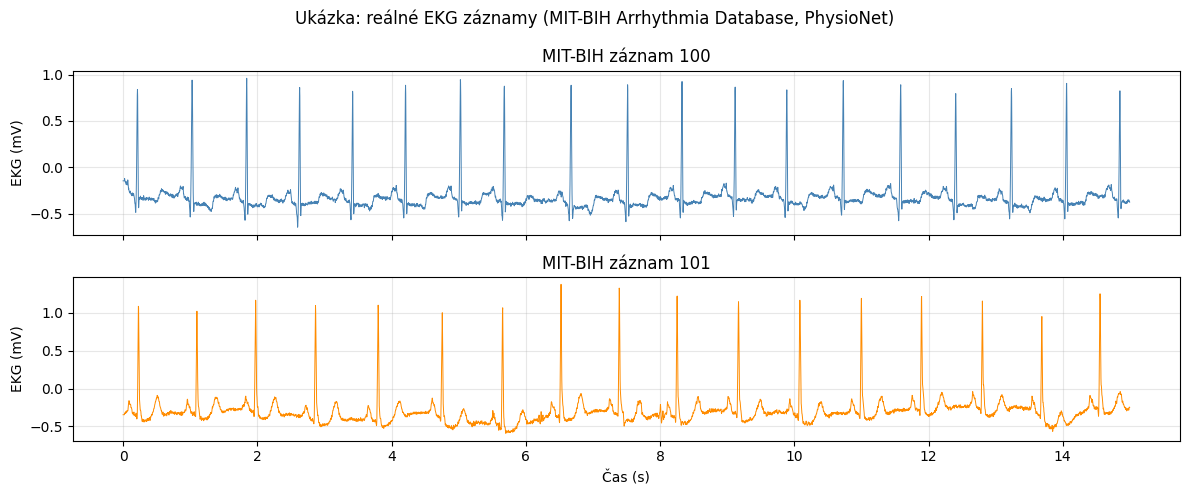

Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


In [1]:
# Ukázkové načtení a zobrazení dvou reálných EKG záznamů pomocí pevně zadané cesty
# Data z MIT-BIH Arrhythmia Database (PhysioNet), fs = 360 Hz
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

data_0 = np.loadtxt("ekg_real/mitbih_100.txt", skiprows=1)
data_1 = np.loadtxt("ekg_real/mitbih_101.txt", skiprows=1)
t0, ekg0 = data_0[:, 0], data_0[:, 1]
t1, ekg1 = data_1[:, 0], data_1[:, 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t0, ekg0, linewidth=0.7, color="steelblue")
ax1.set_ylabel("EKG (mV)")
ax1.set_title("MIT-BIH záznam 100")
ax1.grid(True, alpha=0.3)
ax2.plot(t1, ekg1, linewidth=0.7, color="darkorange")
ax2.set_xlabel("Čas (s)")
ax2.set_ylabel("EKG (mV)")
ax2.set_title("MIT-BIH záznam 101")
ax2.grid(True, alpha=0.3)
plt.suptitle("Ukázka: reálné EKG záznamy (MIT-BIH Arrhythmia Database, PhysioNet)")
plt.tight_layout()
plt.show()
print(f"Délka záznamu: {t0[-1]:.1f} s, vzorkovací frekvence: {1/(t0[1]-t0[0]):.0f} Hz")


## Zadání

Máš k dispozici dvě skupiny EKG záznamů (5 pacientů v každé skupině):

- **`ekg_klid/`** – záznamy v klidu (~60–70 BPM)
- **`ekg_zatez/`** – záznamy při zátěži (~95–110 BPM)

Každý soubor `.txt` je tabulka se dvěma sloupci: `cas[s]` (čas v sekundách) a `ekg[mV]` (amplituda signálu).
První řádek je záhlaví, proto použij `np.loadtxt(soubor, skiprows=1)`.

Proveď postupně tyto kroky:

1. **Načti a vykresli** jeden EKG signál – ukaž, jak vypadá.
2. **Naprahuj signál** – najdi vzorky nad prahem (R-vrcholy = srdeční údery).
3. **Detekuj vrcholy** – z každé skupiny nad prahem vyber jeden bod (náběžná hrana).
4. **Spočítej tepovou frekvenci** (BPM) z časů nalezených vrcholů.
5. **Zpracuj všechny záznamy** obou skupin a porovnej TF boxplotem.


### Krok 1 – Načtení a vykreslení EKG signálu

**Cíl:** Načíst EKG soubory a vizuálně ověřit signál (osa času v sekundách, jsou viditelné R-vlny).

**Jak na to:**

- Soubory najdi přes `glob.glob("ekg_klid/*.txt")` a `glob.glob("ekg_zatez/*.txt")` (+ `sorted()`).
- `np.loadtxt(soubor, skiprows=1)` vrátí 2D matici (N, 2). Sloupec 0 je čas v sekundách, sloupec 1 amplituda
  v mV. První řádek souboru je hlavička — proto `skiprows=1`.
- Rozbal data: `t = data[:, 0]`, `ekg = data[:, 1]`.

**Jak vizualizovat:**

- Vykresli jeden signál (třeba první soubor z `ekg_klid/`) jako spojnicový graf, `plt.subplots(figsize=(12, 3))`.
- Osa X = čas (s), osa Y = EKG (mV). Přidej titulek s názvem pacienta a mřížku.
- `linewidth=0.8` dělá signál čitelnější — R-vlny budou ostré špičky směrem nahoru.

Načteno 7 klidových a 6 zátěžových záznamů
Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


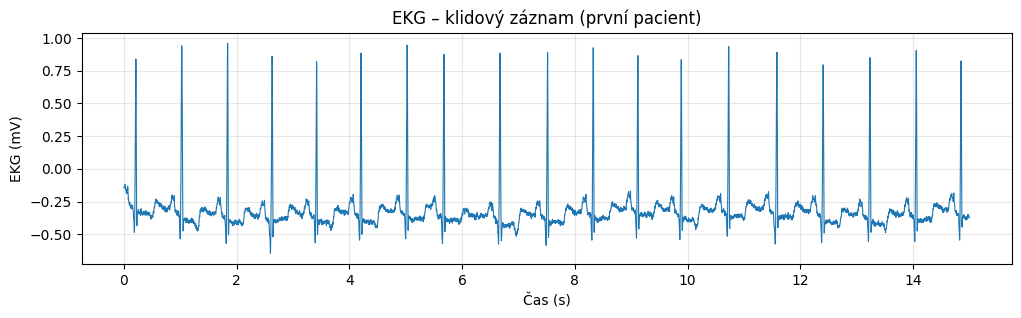

In [8]:
%matplotlib inline
import glob
import numpy as np
import matplotlib.pyplot as plt

# 1) seznamy souborů
files_kliii  = sorted(glob.glob("ekg_klid/*.txt"))
files_zaaa = sorted(glob.glob("ekg_zatez/*.txt"))

# 2) načti první klidový záznam
data0 = np.loadtxt(files_kliii[0], skiprows=1)
t   = data0[:, 0]
ekg = data0[:, 1]

print(f"Načteno {len(files_kliii)} klidových a {len(files_zaaa)} zátěžových záznamů")
print(f"Délka záznamu: {t[-1]:.1f} s, vzorkovací frekvence: {1/(t[1]-t[0]):.0f} Hz")

# 3) vykreslení
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.set_title("EKG – klidový záznam (první pacient)")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.3)
plt.show()

### Krok 2 – Prahování: které vzorky jsou nad hranicí?

**Cíl:** Vyrobit **logickou masku** — pole stejné délky jako signál, `True` tam, kde je amplituda nad prahem.
To jsou místa, kde se nachází R-vlny.

**Jak na to:**

- Zvol práh, např. `PRAH = 0.5` mV.
- Masku získáš rovnou: `nad_prahem = ekg > PRAH`.

**Jak vizualizovat:**

- Vykresli signál jako spojnicový graf.
- Přes něj nakresli vodorovnou čáru prahu: `ax.axhline(PRAH, color="tomato", linestyle="--")`.
- Barevně vyznač oblasti nad prahem: `ax.fill_between(t, PRAH, ekg, where=nad_prahem, alpha=0.3, color="tomato")`.
- Přidej legendu — ať je jasné, co je práh a co nad ním.

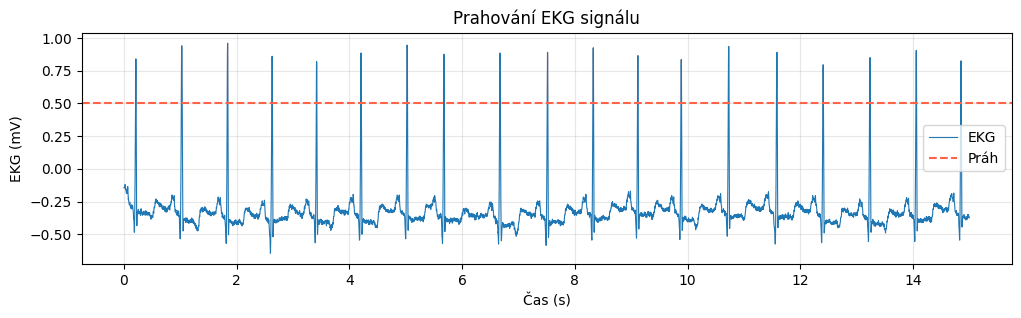

In [9]:
PRAH = 0.5

# logická maska
npra = ekg > PRAH

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8, label="EKG")
ax.axhline(PRAH, color="tomato", linestyle="--", label="Práh")

ax.fill_between(t, PRAH, ekg, where=npra, alpha=0.3, color="tomato")

ax.set_title("Prahování EKG signálu")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### Krok 3 – Detekce R-vrcholů: jeden bod na jeden úder

**Cíl:** Z každé skupiny `True` hodnot v `nad_prahem` vybrat **právě jeden bod** — označíme jím R-vrchol.
Použijeme „sestupnou hranu": poslední `True` před návratem na `False`.

**Jak na to:**

- `np.roll(nad_prahem, -1)` posune pole o jedno místo doleva. Každý prvek si tak „prohlíží" svého pravého souseda.
- Vzorek, který je `True` a zároveň má souseda `False`, je **konec skupiny** → jeden bod na každý úder.
- V Pythonu: `vrcholy = nad_prahem & ~np.roll(nad_prahem, -1)`.
- Poslední vzorek nastav na `False` (okrajový efekt `roll`): `vrcholy[-1] = False`.
- Indexy nalezených vrcholů získáš pomocí `np.where(vrcholy)[0]`.

**Jak vizualizovat:**

- Vykresli signál a na každý R-vrchol umísti výrazný bod pomocí `ax.scatter()` — barevný kruh červenou/tomato,
  `s=60, zorder=5`.
- Do titulku nebo legendy napiš, kolik vrcholů jsi našel.

Nalezeno vrcholů: 19


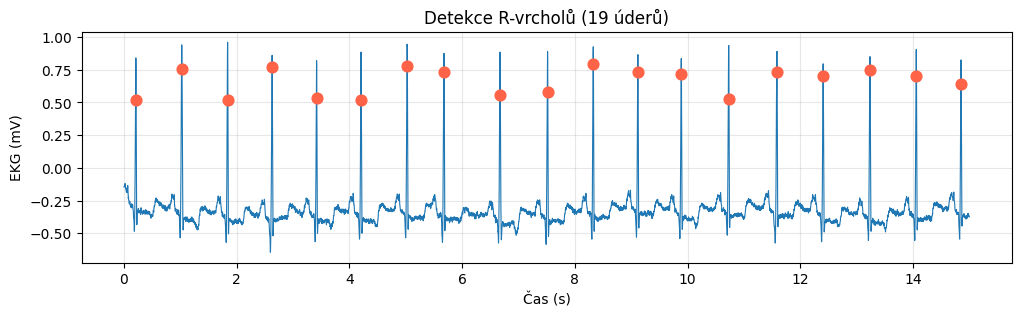

In [10]:
# sestupná hrana (konec oblasti nad prahem)
vrccc = npra & ~np.roll(npra, -1)
vrccc[-1] = False

vrccc_idx = np.where(vrccc)[0]

print(f"Nalezeno vrcholů: {len(vrccc_idx)}")

# vizualizace
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.scatter(t[vrccc_idx], ekg[vrccc_idx], color="tomato", s=60, zorder=5)

ax.set_title(f"Detekce R-vrcholů ({len(vrccc_idx)} úderů)")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.3)
plt.show()

### Krok 4 – Výpočet tepové frekvence

**Cíl:** Z časů R-vrcholů spočítat průměrnou tepovou frekvenci v BPM.

**Jak na to:**

- `cas_vrcholu = t[vrcholy_idx]` — časy, kdy každý úder nastal.
- `np.diff(cas_vrcholu)` — rozdíly mezi sousedními vrcholy = **R-R intervaly** v sekundách.
- Průměrná TF v BPM: `60 / rr_intervaly.mean()` (jeden úder za T sekund → 60/T úderů za minutu).

**Jak vizualizovat:** graf není potřeba, stačí dvě čísla (R-R interval a TF).

In [11]:
cas_vrccc = t[vrccc_idx]

rr_interrr = np.diff(cas_vrccc)
tf_bpm = 60 / rr_interrr.mean()

print(f"Průměrný R-R interval: {rr_interrr.mean():.3f} s")
print(f"Tepová frekvence: {tf_bpm:.1f} BPM")

Průměrný R-R interval: 0.813 s
Tepová frekvence: 73.8 BPM


### Krok 5 – Srovnání skupin: boxplot

**Cíl:** Aplikovat celý postup (prahování → detekce → TF) na **všechny záznamy** obou skupin a porovnat
klidové TF se zátěžovými boxplotem.

**Jak na to:**

- Napiš si pomocnou funkci `spocitej_tf(soubor)`, která načte soubor a vrátí průměrnou TF v BPM.
  Opakuješ tím přesně kroky 1–4, ale zabalené do jedné funkce.
- Zavolej ji pro všechny soubory v obou skupinách → dva seznamy `tf_klid`, `tf_zatez`.

**Jak vizualizovat:**

- `ax.boxplot([tf_klid, tf_zatez], tick_labels=["Klidová", "Zátěžová"])`.
- Popiš osu Y (`"Tepová frekvence (BPM)"`) a přidej titulek.

**Co bys měl vidět:** klidová skupina je kolem 60–75 BPM, zátěžová kolem 95–110 BPM. Boxy by měly být
zřetelně oddělené (může se objevit outlier z reálného MIT-BIH záznamu s arytmií).

Klidová TF (BPM):  ['73.8', '67.0', '62.0', '65.0', '68.0', '63.0', '67.0']
Zátěžová TF (BPM): ['65.7', '98.0', '103.0', '107.0', '95.0', '101.0']


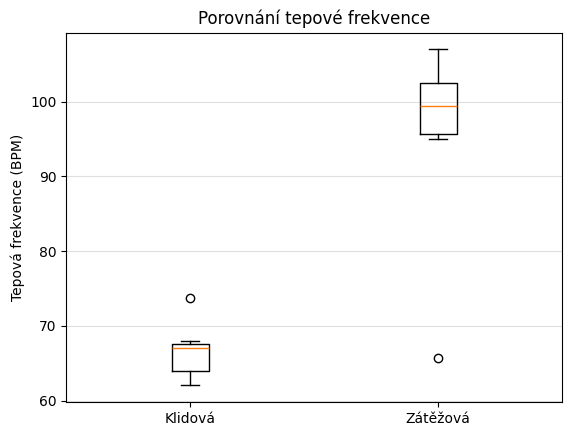

In [12]:
PRAH = 0.5

def spocitej_tf(soubor):
    data = np.loadtxt(soubor, skiprows=1)
    t = data[:, 0]
    ekg = data[:, 1]

    npra = ekg > PRAH
    vrccc = npra & ~np.roll(npra, -1)
    vrccc[-1] = False

    idx = np.where(vrccc)[0]

    if len(idx) < 2:
        return np.nan

    cas = t[idx]
    rr = np.diff(cas)

    return 60 / rr.mean()


# výpočet pro všechny soubory
tf_kliii  = [spocitej_tf(f) for f in files_kliii]
tf_zaaa = [spocitej_tf(f) for f in files_zaaa]

print("Klidová TF (BPM): ", [f"{x:.1f}" for x in tf_kliii])
print("Zátěžová TF (BPM):", [f"{x:.1f}" for x in tf_zaaa])

# boxplot
fig, ax = plt.subplots()
ax.boxplot([tf_kliii, tf_zaaa], tick_labels=["Klidová", "Zátěžová"])

ax.set_ylabel("Tepová frekvence (BPM)")
ax.set_title("Porovnání tepové frekvence")
ax.grid(True, axis="y", alpha=0.4)

plt.show()

### Interpretace

Krátce komentuj:

- Jak se klidová a zátěžová skupina liší v průměrné tepové frekvenci?
- Objevil ses outlier? Odkud by mohl pocházet (reálná arytmie, šum, špatně zvolený práh)?
- Proč je taková jednoduchá detekce (pevný práh + sestupná hrana) v praxi omezená? Co by bylo potřeba
  udělat pro robustnější detekci R-vrcholů (filtrace pásmovou propustí, adaptivní práh, Pan–Tompkinsův
  algoritmus)?

*Sem napiš svou odpověď.*